In [1]:
# 고객 이탈에 여부 분류 모델
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
# 데이터 읽기
import pandas as pd
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 1. 데이터 기본정보 확인
df.info()
# TotalCharges      7043 non-null   object 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# TotalCharges의 dtype이 맞지않는다.

In [4]:
df.select_dtypes(include=['object'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [5]:
bad_values = []
for val in df['TotalCharges']:
    try:
        float(val)
    except Exception as e:
        bad_values.append(val)  # 에러 발생 값 저장
print(bad_values)
# 빈칸으로 되어있다.

[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']


In [6]:
# 결측치 NaN으로 변환하기
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [7]:
df.info()
# TotalCharges      7043 non-null   object 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# 범주형 데이터를 수치형 데이터로 변환하기
# 방법 1: get_dummies()
# 방법 2 : sklearn.preprocessing.OneHotEncoder 사용
# 방법 3 : df['Churn'] = df.Churn.map({'Yes':1,'No':0})
# 방법 4 : df['Churn'] = df.Churn.apply(lambda x : 1 if x=='Yes' else 0 )
# Churn Yes(1) / No(0)

df['Churn'] = df.Churn.map({'Yes':1,'No':0})
print(df.Churn)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# 클래스 불균형 점검 및 불균형 맞춰보기
# 학습용 데이터 임의 지정하여 진행 : MonthlyCharges,  TotalCharges -> 실제에서는 데이터 지정과정중에 고민하는 시간이 필요

In [ ]:
# baseline 데이터 및 모델 생성

# 피처 선택
base_df = df.select_dtypes(include={'int','float'}).copy()
# 선택된 데이터 항목 : Churn, TotalCharges, MonthlyCharges, tenure, SeniorCitizen
# 아까 말했다 시피 임의로 데이터를 선정, 긁어온거다.

# 결측치 처리
base_df = base_df.dropna()

X = base_df.drop(columns=['Churn']).to_numpy()
y = base_df.Churn

# 판다스 보다, 넘파이 형태가 처리속도가 조금 더 빠르다

# 데이터 분할
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 모델 생성
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

# 모델 학습
knn.fit(x_train_scaled,y_train)

# 모델 평가
from sklearn.metrics import classification_report
predict = knn.predict(x_test_scaled)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.82      0.88      0.84      1033
           1       0.57      0.45      0.51       374

    accuracy                           0.76      1407
   macro avg       0.69      0.66      0.67      1407
weighted avg       0.75      0.76      0.75      1407



In [17]:
# 불균형 확인
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [18]:
y.value_counts(normalize=True)  # 불균형 비율 확인

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

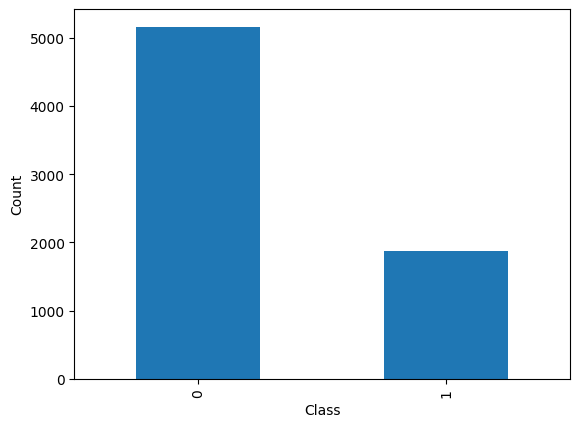

In [20]:
# 시각화로 불균형 비율 확인
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# 어떤 불균형 조정으로 하는 방법으로 할지 알아보기.

In [24]:
# 데이터 언더 샘플링
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# 데이터 분할
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_resampled,y_resampled,stratify=y_resampled,test_size=0.2,random_state=42)

# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 모델 생성
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

# 모델 학습
knn.fit(x_train_scaled,y_train)

# 모델 평가
from sklearn.metrics import classification_report
predict = knn.predict(x_test_scaled)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.72      0.71      0.71       374
           1       0.71      0.72      0.72       374

    accuracy                           0.72       748
   macro avg       0.72      0.72      0.72       748
weighted avg       0.72      0.72      0.72       748



In [ ]:
# 오버 샘플링
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 데이터 분할
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_resampled,y_resampled,stratify=y_resampled,test_size=0.2,random_state=42)

# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 모델 생성
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

# 모델 학습
knn.fit(x_train_scaled,y_train)

# 모델 평가
from sklearn.metrics import classification_report
predict = knn.predict(x_test_scaled)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77      1033
           1       0.77      0.78      0.78      1033

    accuracy                           0.77      2066
   macro avg       0.77      0.77      0.77      2066
weighted avg       0.77      0.77      0.77      2066



In [ ]:
# 오버 샘플링으로 모델을 만드는 것이 더 성능이 좋은 것을 확인할 수 있다.

In [ ]:
# 이전에 하던 7.4.review_student_try1는 모델의 성능을 늘리기 위한 노력이였고, 그걸 학습시키는 데이터 자체가
# 불균형 상태라서 그점을 조정하는 것에 집중하는 게 이번 활동이였다...

# 그래서 동일한 모델로 데이터 불균형을 어떻게 설정하면 좋을지에 대해서 정리해보고자한다. 

In [ ]:
# 이전 7.4.review_student_try1에서 다룬 모델 성능올리기 내용 :
# 스케일링 항목별 비교
# 최적의 k값 찾기

# 이거 서순도 영향있을것 같다...

In [ ]:
# 오버샘플링에서 좀더 상세하게 무엇을 조정하면 좋을지에 대해서 알아보면 될듯하다.
# 그러고나서 이전에 찾은 모델향상 까지 더해서 성능을 올려보자.

In [ ]:
# 오버 샘플링